# Regression Modeling (Lasso L1, Random Forest) Team B

## Step 1: Data Preparation and Loading

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
 
df_main = pd.read_csv('feature_engineered_dataset.csv')
df_scaled = pd.read_csv('scaled_features_dataset.csv')
df_pca = pd.read_csv('pca_reduced_dataset.csv')
 
target_main = 'actual_time'
target_scaled = 'actual_time_standard'
 
X_main = df_main.drop(columns=[target_main])
y_main = df_main[target_main]
 
X_scaled = df_scaled.drop(columns=[target_scaled])
y_scaled = df_scaled[target_scaled]
 
X_pca = df_pca.drop(columns=['is_cutoff'])
y_pca = y_scaled  
 
X_train_main, X_test_main, y_train_main, y_test_main = train_test_split(
    X_main, y_main, test_size=0.2, random_state=42
)
 
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)
 
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y_pca, test_size=0.2, random_state=42
)

print("Data preparation complete.")
print("Main Features (Random Forest):", X_main.shape)
print("Scaled Features (Lasso):", X_scaled.shape)
print("PCA Features:", X_pca.shape)


Data preparation complete.
Main Features (Random Forest): (140909, 40)
Scaled Features (Lasso): (138988, 108)
PCA Features: (138988, 7)


## Step 2: Lasso Regression (L1 Norm)

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv("feature_engineered_dataset.csv")

df = df.select_dtypes(include=[np.number])
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

X = df.drop(["actual_time", 
             "osrm_distance", 
             "cutoff_factor", 
             "actual_distance_to_destination", 
             "osrm_time", 
             "time_difference"], axis=1)
y = df["actual_time"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


alpha_values = [0.05, 0.08, 0.1, 0.12, 0.15, 0.2]
lasso_cv = LassoCV(alphas=alpha_values, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)


y_train_pred = lasso_cv.predict(X_train_scaled)
y_test_pred = lasso_cv.predict(X_test_scaled)



def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_idx = y_true != 0
    return np.mean(np.abs((y_true[non_zero_idx] - y_pred[non_zero_idx]) / y_true[non_zero_idx])) * 100

lasso_results = {
    "Best Alpha": lasso_cv.alpha_,
    "Train R²": r2_score(y_train, y_train_pred),
    "Test R²": r2_score(y_test, y_test_pred),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    "Train MAE": mean_absolute_error(y_train, y_train_pred),
    "Test MAE": mean_absolute_error(y_test, y_test_pred),
    "Train MAPE": mape(y_train, y_train_pred),
    "Test MAPE": mape(y_test, y_test_pred)
}



pd.DataFrame(lasso_results, index=["LassoCV (No Leakage)"]).T

,LassoCV (No Leakage)
Best Alpha,0.050000
Train R²,0.981851
Test R²,0.982706
Train RMSE,81.688854
Test RMSE,78.988418
Train MAE,38.237644
Test MAE,38.382639
Train MAPE,40.475763
Test MAPE,42.204491


## Step 3: Random Forest Regression

Fitting 2 folds for each of 5 candidates, totalling 10 fits
RMSE: 225.23
R2 Score: 0.8599
Best Parameters: {'regressor__n_estimators': 50, 'regressor__min_samples_split': 5, 'regressor__min_samples_leaf': 2, 'regressor__max_features': 'sqrt', 'regressor__max_depth': None, 'regressor__bootstrap': True}


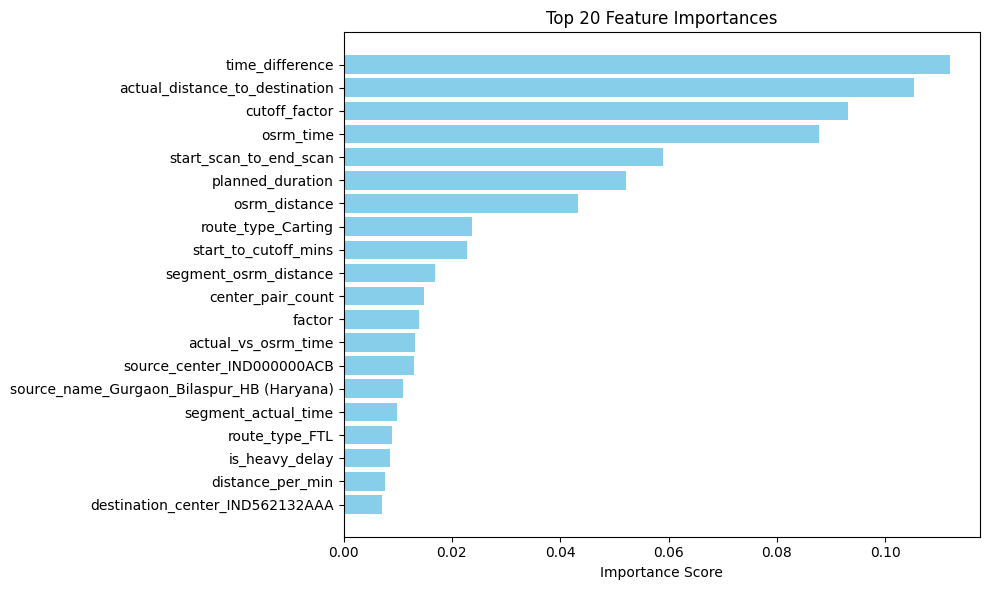

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

categorical_cols = X_train_main.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train_main.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='mean'), numerical_cols),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, oob_score=True, n_jobs=-1))
])

param_dist = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [10, None],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__max_features': ['sqrt'],
    'regressor__bootstrap': [True]
}

X_train_main.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_main.replace([np.inf, -np.inf], np.nan, inplace=True)

X_train_sample = X_train_main.sample(frac=0.3, random_state=42)
y_train_sample = y_train_main.loc[X_train_sample.index]

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    verbose=1,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_sample, y_train_sample)

best_params = random_search.best_params_
pipeline.set_params(**best_params)
pipeline.fit(X_train_main, y_train_main)

y_pred = pipeline.predict(X_test_main)

rmse = np.sqrt(mean_squared_error(y_test_main, y_pred))
r2 = r2_score(y_test_main, y_pred)
print("RMSE:", round(rmse, 4))
print("R2 Score:", round(r2, 4))
print("Best Parameters:", best_params)

onehot_names = pipeline.named_steps['preprocessor'].transformers_[1][1]\
    .named_steps['encoder'].get_feature_names_out(categorical_cols)
all_features = np.concatenate([numerical_cols, onehot_names])

importances = pipeline.named_steps['regressor'].feature_importances_
importance_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [18]:
from sklearn.metrics import mean_absolute_error

# Predictions
y_train_pred = pipeline.predict(X_train_main)
y_test_pred = pipeline.predict(X_test_main)

# Train Metrics
train_rmse = np.sqrt(mean_squared_error(y_train_main, y_train_pred))
train_mae = mean_absolute_error(y_train_main, y_train_pred)
train_r2 = r2_score(y_train_main, y_train_pred)

# Test Metrics
test_rmse = np.sqrt(mean_squared_error(y_test_main, y_test_pred))
test_mae = mean_absolute_error(y_test_main, y_test_pred)
test_r2 = r2_score(y_test_main, y_test_pred)

# Print Results
print("Train Metrics:")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"R² Score: {train_r2:.4f}\n")

print("Test Metrics:")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"R² Score: {test_r2:.4f}")


Train Metrics:
RMSE: 222.4399
MAE: 117.1622
R² Score: 0.8642

Test Metrics:
RMSE: 225.2300
MAE: 119.3494
R² Score: 0.8599


In [22]:
# Custom MAPE function (reuse same as before)
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_idx = y_true != 0
    return np.mean(np.abs((y_true[non_zero_idx] - y_pred[non_zero_idx]) / y_true[non_zero_idx])) * 100

# Collect Random Forest metrics
rf_results = {
    "Train R²": r2_score(y_train_main, pipeline.predict(X_train_main)),
    "Test R²": r2_score(y_test_main, y_pred),
    "Train RMSE": np.sqrt(mean_squared_error(y_train_main, pipeline.predict(X_train_main))),
    "Test RMSE": np.sqrt(mean_squared_error(y_test_main, y_pred)),
    "Train MAE": mean_absolute_error(y_train_main, pipeline.predict(X_train_main)),
    "Test MAE": mean_absolute_error(y_test_main, y_pred),
    "Train MAPE": mape(y_train_main, pipeline.predict(X_train_main)),
    "Test MAPE": mape(y_test_main, y_pred)
}


## Step 4 Model Comparison

In [23]:
comparison_df = pd.DataFrame({
    "LassoCV (No Leakage)": lasso_results,
    "RandomForest": rf_results
})

comparison_df


,LassoCV (No Leakage),RandomForest
Best Alpha,0.050000,NaN
Train R²,0.981851,0.864240
Test R²,0.982706,0.859886
Train RMSE,81.688854,222.439885
Test RMSE,78.988418,225.229976
Train MAE,38.237644,117.162186
Test MAE,38.382639,119.349382
Train MAPE,40.475763,71.168778
Test MAPE,42.204491,73.020186


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-8))) * 100

mae = mean_absolute_error(y_test_main, y_pred)
mse = mean_squared_error(y_test_main, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_main, y_pred)
mape = mean_absolute_percentage_error(y_test_main, y_pred)

print("Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")


Evaluation Metrics:
MAE  : 119.3494
MSE  : 50728.5420
RMSE : 225.2300
R²   : 0.8599
MAPE : 73.02%


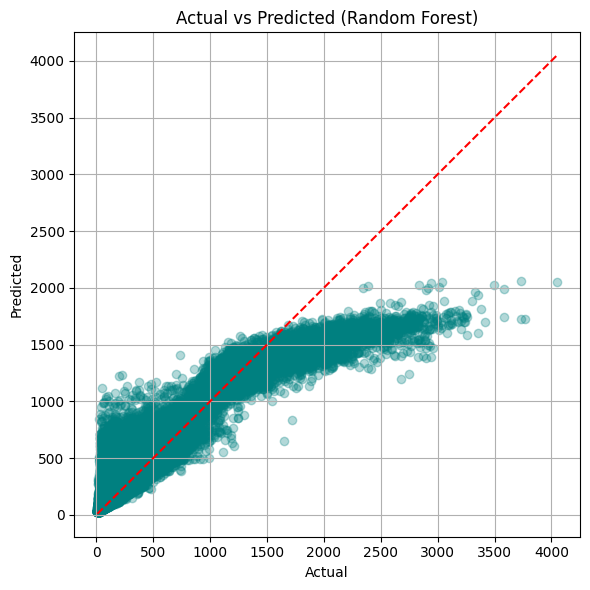

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test_main, y_pred, alpha=0.3, color='teal')
plt.plot([y_test_main.min(), y_test_main.max()], [y_test_main.min(), y_test_main.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.grid(True)
plt.tight_layout()
plt.show()
